# Assessment Outline
## Classification of Voter Turnout Percent
### 2025 Gubernatorial Elections

**Three Primary Methods**
* Regression (LASSO) to find the best columns
    * serves as Feature Reduction
* Random Forest Classification
* Some kind of model interpretation: SHAP?

## Data Cleaning
### VA Census Tracts
* Import Tracts Shapfile
* Keep Only Geometry and ID Column for now

### Voting Precincts
* Identify and clean the merge column
* Keep only the merge column and geometry

### Voter Turnout
* Identify and clean the merge column
* Keep turnout and active voters
* Create turnout percent column
* Keep only merge key and turnout percent (This will be the dependent variable for the model)

### ACS

### All
* Join all Datasets Together

## Census Tracts

<Axes: >

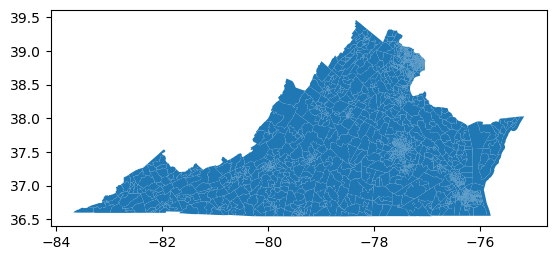

In [1]:
# Import from my github
import geopandas as gpd
url = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/census_tracts.zip"
ct = gpd.read_file(url)
ct.plot()
#ct.head(2)

In [2]:
# Keep only necessary columns: GEOID (for merging), geometry, ALAND (for population density later)
ct = ct[["GEOID", "geometry", "ALAND"]]
#ct.head(2)

## Voter Precincts

The data in this next section comes from [this github repository](https://github.com/21MetcalfJ/2024Precincts). 

The pecinct shapefile has been stored by 21MetcalfJ and collected by Twitter/X user @sz1176491. This repository contains precinct shapefiles for all 50 US states and Washington D.C. As noted in the repository, there is no uniform method of storing precinct boundary data, however several states maintain publically available shapefiles, and Virginia is one of them. This means that the shapefile of Virginia precinct stored in the repository comes from [Redistricting Data Hub](https://redistrictingdatahub.org/dataset/virginia-2024-general-election-precinct-level-results-and-boundaries/).

<Axes: >

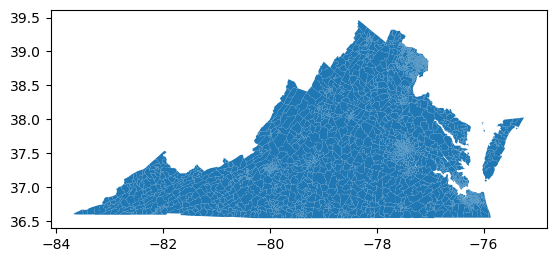

In [3]:
# Import from an external GitHub
url1 = "https://raw.githubusercontent.com/21MetcalfJ/2024Precincts/main/states/Virginia/VA24.zip"
vp = gpd.read_file(url1)
vp.plot()

In [4]:
# Keep only necessary columns: PCTKEY, geometry
vp = vp[["PCTKEY", "geometry"]].copy()
#vp.head(2)

## Voter Turnout

In [5]:
# Import from my GitHub
import pandas as pd
url2 = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/2025_election_turnout.csv"
vt = pd.read_csv(url2)
#vt.head(2)

In [6]:
# Create PCTKEY Column
# Keep only the precinct number per county
vt["precinct"] = vt["precinct"].str.split(" - ").str[0]
vt["PCTKEY"] = vt["locality"] + "-" + vt["precinct"]
# Keep only necessary columns: PCTKEY, Turnoutpct
vt = vt[["PCTKEY", "TotalVoteTurnout", "ActiveRegisteredVoters"]].copy()
#vt.head(2)

## First Merge - Turnout and Precinct

* I will have to ensure that the PCT column is correct for each precinct before the merge can proceed

In [7]:
# Extract values present in one dataset and not the other
missing_vp = vp[~vp["PCTKEY"].isin(vt["PCTKEY"])]
missing_vt = vt[~vt["PCTKEY"].isin(vp["PCTKEY"])]

# Display
#missing_vp.head(2)
#missing_vt.head(2)

# The main problem is that some areas store the key as BRISTOL CITY-001 in the turnout, but BRISTOL CITY-1 in the precinct

#### Pad the PCTKEY column so that fits the format of "LOCALITY-00#"

In [8]:
import re

def pad_precinct_num(key):
    # Split on last hyphen
    try:
        locality, precinct = key.rsplit("-", 1)
    except ValueError:
        return key

    # Extract digits
    digits = re.findall(r"\d+", precinct)
    if not digits:
        return key

    padded = digits[0].zfill(3)
    return f"{locality}-{padded}"

vt["PCTKEY"] = vt["PCTKEY"].apply(pad_precinct_num)
vp["PCTKEY"] = vp["PCTKEY"].apply(pad_precinct_num)

missing_vp = vp[~vp["PCTKEY"].isin(vt["PCTKEY"])]
missing_vt = vt[~vt["PCTKEY"].isin(vp["PCTKEY"])]

In [9]:
print(len(missing_vp)) # was around 300 before
print(len(missing_vt)) # was around 300 before

16
12


#### Okay that solved most of the problem. Let's go back in an fix the rest

In [10]:
# Second cleaning: cut after the second hyphen in the key column
def cut_after_second_hyphen(key):
    parts = key.split("-")
    return "-".join(parts[:2])  # keep only first two parts

vt["PCTKEY"] = vt["PCTKEY"].apply(cut_after_second_hyphen)

### Still have some work to do. 
By Now I know that 4 precints in are not present in the voter record, and one has been labelled differenly.
Let's finish cleaning the merge key and rename the one that needs it

In [11]:
# Rename mismatch fairfax county precint
vt["PCTKEY"] = vt["PCTKEY"].replace({"FAIRFAX COUNTY-637": "FAIRFAX COUNTY-700"})

# Strip internal spaces in the merge keys
vt["PCTKEY"] = vt["PCTKEY"].str.strip()
vp["PCTKEY"] = vp["PCTKEY"].str.strip()

missing_vp = vp[~vp["PCTKEY"].isin(vt["PCTKEY"])]
missing_vt = vt[~vt["PCTKEY"].isin(vp["PCTKEY"])]
print(len(missing_vp))
print(len(missing_vt))

# Perfect, the four precints that aren't in the voting record will simply be removed in the merge.

4
0


#### Initiate Merge
* Locate keys present in both datasets
* Remove those that aren't
* Join the datasets on the PCTKEY column

In [12]:
# Locate the keys in both datasets
valid_keys = set(vt["PCTKEY"]).intersection(vp["PCTKEY"])
# Filter only the valid keys
vt_clean = vt[vt["PCTKEY"].isin(valid_keys)]
vp_clean = vp[vp["PCTKEY"].isin(valid_keys)]
# join the datasets
voting = vp_clean.merge(vt_clean, on="PCTKEY", how="left")
#voting.head(5)

## Census Data

In [13]:
# Read in csv files from my GitHub
url3 = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/demographics.csv"
url4 = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/social.csv"
url5 = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/housing.csv"
url6 = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/econ.csv"

def clean_acs_csv(url):
    df = pd.read_csv(url, header=None, low_memory=False)
    # Row 1 contains the real ACS variable names
    df.columns = df.iloc[1]
    # Drop the first two rows (label row + header row)
    df = df.drop([0, 1]).reset_index(drop=True)
    return df

dem = clean_acs_csv(url3)
soc = clean_acs_csv(url4)
house = clean_acs_csv(url5)
econ = clean_acs_csv(url6)

In [14]:
#dem.head(1)
#soc.head(1)
#house.head(1)
#econ.head(1)

#### Let's Start Cleaning the Census Data

In [15]:
def clean_demographic(df):
    df.columns = df.columns.astype(str)
    # The correct ACS DP05 denominator
    total_pop_col = "Estimate!!SEX AND AGE!!Total population"
    if total_pop_col not in df.columns:
        print("Could not find:", total_pop_col)
        return df
    keep_mask = (
        df.columns.str.startswith("Percent!!") |
        (df.columns == "Geography") |
        (df.columns == total_pop_col)
    )
    df = df.loc[:, keep_mask].copy()
    # Clean names
    df.columns = [c.split("!!")[-1] if "!!" in c else c for c in df.columns]
    return df

# Force column names to be strings before running the function
dem.columns = dem.columns.astype(str)
dem = clean_demographic(dem)
#dem.head(2)

In [16]:
def clean_pct_table(df):
    # ensure column names are strings
    df.columns = df.columns.astype(str)
    # Keep Geography + percent columns
    keep_mask = (
        df.columns.str.startswith("Percent!!") |
        (df.columns == "Geography") 
    )
    df = df.loc[:, keep_mask].copy()
    # Clean names: keep only the last part after "!!"
    df.columns = [
        c.split("!!")[-1] if "!!" in c else c
        for c in df.columns
    ]
    return df

# apply function
soc = clean_pct_table(soc)
house = clean_pct_table(house)
econ = clean_pct_table(econ)

# inspect
#soc.head(2)
#house.head(2)
#econ.head(2)

In [17]:
# Now I want to make a GEOID column that takes the last 11 digits of the Geography columns
# These 11 digits line up with the above census shapefile
for df in [soc, house, econ, dem]:
    df["GEOID"] = df["Geography"].astype(str).str[-11:]
    df.drop(columns=["Geography"], inplace = True)

In [18]:
# Inspect
#dem.columns
#soc.head(2)
#house.head(2)
#econ.head(2)
# Looks all good

## Second Merge: Census Tracts and Census Data

In [19]:
# This should be more simple
# Use the GEOID columns
census = (
    ct
    .merge(dem, on="GEOID", how="left")
    .merge(soc, on="GEOID", how="left")
    .merge(house, on="GEOID", how="left")
    .merge(econ, on="GEOID", how="left")
)

# Remove White space in column names
census.columns = census.columns.str.strip()

# inspect
print(len(census))
#census.head(2)

2198


#### Not Done Yet with the Census Data
* Remove Columns with (X) or NaN values
* Remove Duplicate Population Column

In [20]:
# remove (X) Columns
mask_any_X = census.apply(lambda col: (col == "(X)").any())
census = census.loc[:, ~mask_any_X]
# drop entirely NaN columns
census = census.dropna(axis=1, how="all")
# create a copy of the duplicate columns with a new name
census["Total_population"] = census.iloc[:, 3]
# drop the original columns
census = census.drop(census.columns[[3, 4]], axis=1)
# inspect
#census.head(2)

In [21]:
# Remove any other duplicates
census = census.loc[:, ~census.columns.duplicated()]
# Let's make values numeric: except geometry and GEOID code
cols = census.columns.difference(["GEOID", "geometry"])
census[cols] = census[cols].apply(pd.to_numeric, errors="coerce")
# Now let's make a population density column
# People per Km^2
# Replace 0 ALAND with a small number close to 0
census["ALAND"] = census["ALAND"].replace(0, 1e-6)
census["Popden_Km"] = round((census["Total_population"]) / (census["ALAND"] / 1000000),3)
#census.head(2)

/opt/conda/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [22]:
# Make a new copy to maintain computation speed
census = census.copy()
#census.tail(2)

## Join the Census Tracts and Vote Data.
They do not follow the same geography
* If 90% of a precinct falls within a tract, that tract gets 90% of the voter turnout and 90% of the active registered voters
* The main limitation of this is that is assumes population is distributed evenly within voting precincts

In [23]:
# Ensure the data is in the same crs
voting = voting.to_crs(3968) # Virginia North Region - Meters
census = census.to_crs(3968)

In [24]:
# Compute precinct areas
voting["precinct_area"] = voting.geometry.area
# intersect the two shapefiles
intersections = gpd.overlay(voting, census, how="intersection")
# area of each intersection
intersections["intersect_area"] = intersections.geometry.area
# how much of each precinct falls within each tract
intersections["pct_of_precinct"] = (intersections["intersect_area"] / intersections["precinct_area"])
# allotcate the voting data propotionally 
intersections["allocated_turnout"] = (intersections["TotalVoteTurnout"] * intersections["pct_of_precinct"])
intersections["allocated_registered"] = (intersections["ActiveRegisteredVoters"] * intersections["pct_of_precinct"])
# aggregate back to the tract level
tract_vote = (
    intersections.groupby("GEOID")[["allocated_turnout", "allocated_registered"]]
    .sum()
    .reset_index()
)
# join back to the census data
data = census.merge(tract_vote, on="GEOID", how="left")
# inspect
#data.head(2)

In [25]:
# Create the voter turnout percent that will become the dependent variable of the model.
data["Turnoutpct"] = round((data["allocated_turnout"] / data["allocated_registered"]) * 100,3)
#data.head(2)

## Quick Chloropleth Map of the turnout pct

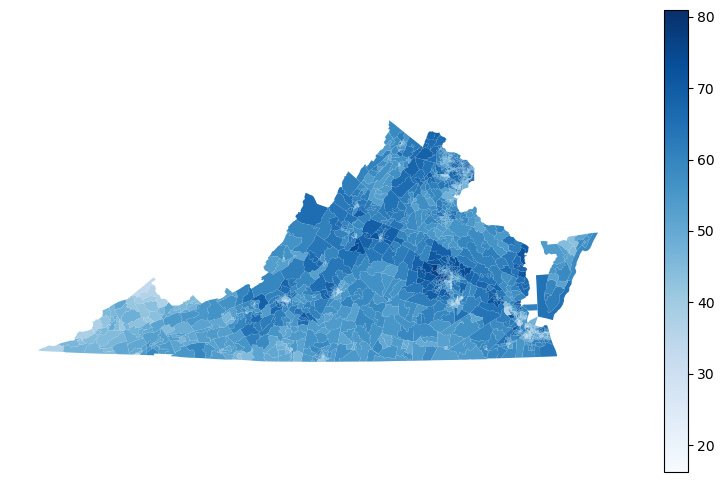

In [26]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 8))

data.plot(
    column="Turnoutpct",
    cmap="Blues",
    linewidth=0,
    legend=True,
    legend_kwds={"shrink": 0.6},  # keeps it small
    ax=ax
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


## Export the new shape file

In [27]:
#data.to_file("complete_data.shp")

In [28]:
#votes_per_tract = data.copy()
# Convert geometry to WKT
#votes_per_tract["geometry"] = votes_per_tract["geometry"].to_wkt()
# Export to CSV
#votes_per_tract.to_csv("votes_per_tract.csv", index=False)